# 04 - EDA: Universal Metadata (WLASL + MS-ASL)

Explores `merged_datasets/universal_metadata_has_video_wlasl_msasl_merged.csv`:
1. Frame count and duration distribution
2. FPS distribution
3. Samples per class
4. Signer vs label relationship
5. Video dimensions
6. Numeric correlations

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, spearmanr

plt.style.use('ggplot')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

In [2]:
PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
CSV_PATH = PROJECT_ROOT / 'merged_datasets' / 'universal_metadata_has_video_wlasl_msasl_merged.csv'

print('CSV_PATH:', CSV_PATH)
print('Exists:', CSV_PATH.exists())

df = pd.read_csv(CSV_PATH)
print('Shape:', df.shape)
df.head()

CSV_PATH: C:\Users\kacpe\source\repos\szum\merged_datasets\universal_metadata_has_video_wlasl_msasl_merged.csv
Exists: True
Shape: (28745, 12)


,label,source,video_path,start_frame,end_frame,length_frames,duration_sec,fps,signer_id,has_video,video_width,video_height
0,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_CBQXPn152YI...,3523,3609.0,87.0,3.440,25.00,msasl_172,True,640.0,360.0
1,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_R_ES8RZua1g...,675,734.0,60.0,1.967,30.00,msasl_40,True,568.0,320.0
2,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_VcRx3U-HpTE...,8111,8197.0,87.0,3.583,24.00,msasl_125,True,1280.0,720.0
3,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,4840,4881.0,42.0,1.368,29.97,msasl_26,True,1280.0,720.0
4,100,msasl,MS-ASL/videos_MS_ASL_raw/msasl_raw_LNEzl4vTVyE...,5514,5545.0,32.0,1.034,29.97,msasl_26,True,1280.0,720.0


In [3]:
def plot_hist(series: pd.Series, title: str, xlabel: str, bins: int = 50, color: str = '#1f77b4') -> None:
    clean = pd.to_numeric(series, errors='coerce').dropna()
    if clean.empty:
        print(f'No data for: {title}')
        return
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(clean, bins=bins, color=color, alpha=0.9)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Count')
    plt.tight_layout()
    plt.show()


def plot_top_bar(series: pd.Series, title: str, xlabel: str, ylabel: str, top_n: int = 20, color: str = '#4c78a8') -> None:
    s = series.dropna()
    if s.empty:
        print(f'No data for: {title}')
        return
    s = s.head(top_n)
    fig, ax = plt.subplots(figsize=(10, 4))
    s.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_heatmap(matrix_df: pd.DataFrame, title: str, cmap: str = 'coolwarm', vmin: float | None = None, vmax: float | None = None) -> None:
    if matrix_df.empty:
        print(f'No data for: {title}')
        return
    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(matrix_df.values, aspect='auto', cmap=cmap, vmin=vmin, vmax=vmax)
    ax.set_xticks(np.arange(len(matrix_df.columns)))
    ax.set_yticks(np.arange(len(matrix_df.index)))
    ax.set_xticklabels(matrix_df.columns, rotation=90)
    ax.set_yticklabels(matrix_df.index)
    ax.set_title(title)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    plt.tight_layout()
    plt.show()


def plot_quantiles(series: pd.Series, title: str, color: str = '#2ca02c') -> None:
    clean = pd.to_numeric(series, errors='coerce').dropna()
    if clean.empty:
        print(f'No data for: {title}')
        return
    q = clean.quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99])
    fig, ax = plt.subplots(figsize=(8, 4))
    q.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel('Quantile')
    ax.set_ylabel('Value')
    plt.tight_layout()
    plt.show()

## 2. Frame Count and Duration Distribution

Distribution snapshots (quantiles)


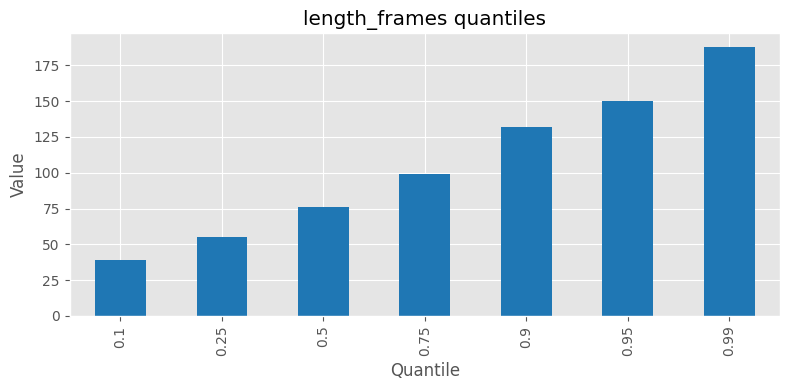

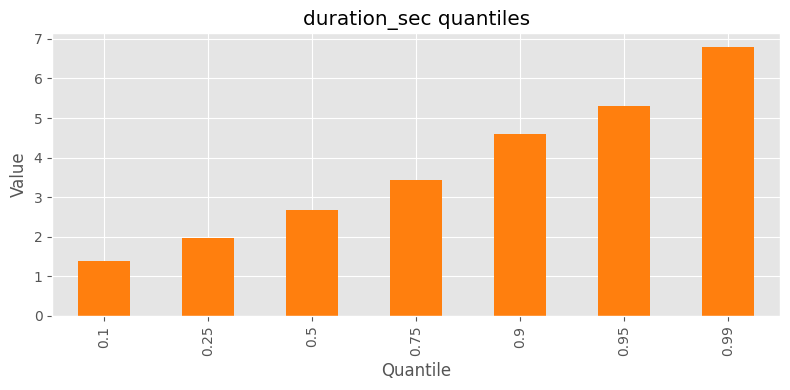

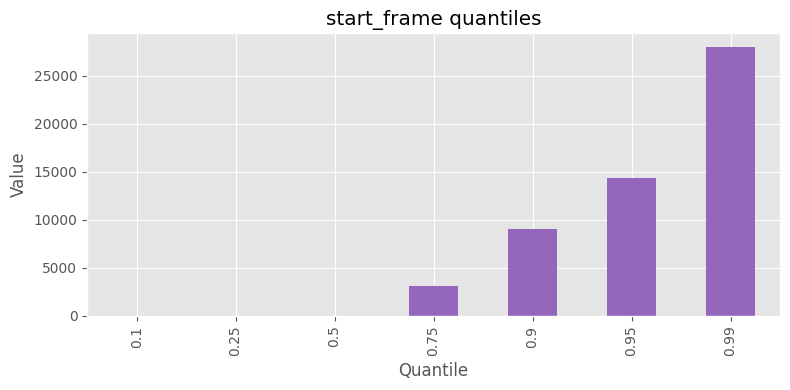

In [4]:
print('Distribution snapshots (quantiles)')
plot_quantiles(df['length_frames'], 'length_frames quantiles', color='#1f77b4')
plot_quantiles(df['duration_sec'], 'duration_sec quantiles', color='#ff7f0e')
plot_quantiles(df['start_frame'], 'start_frame quantiles', color='#9467bd')

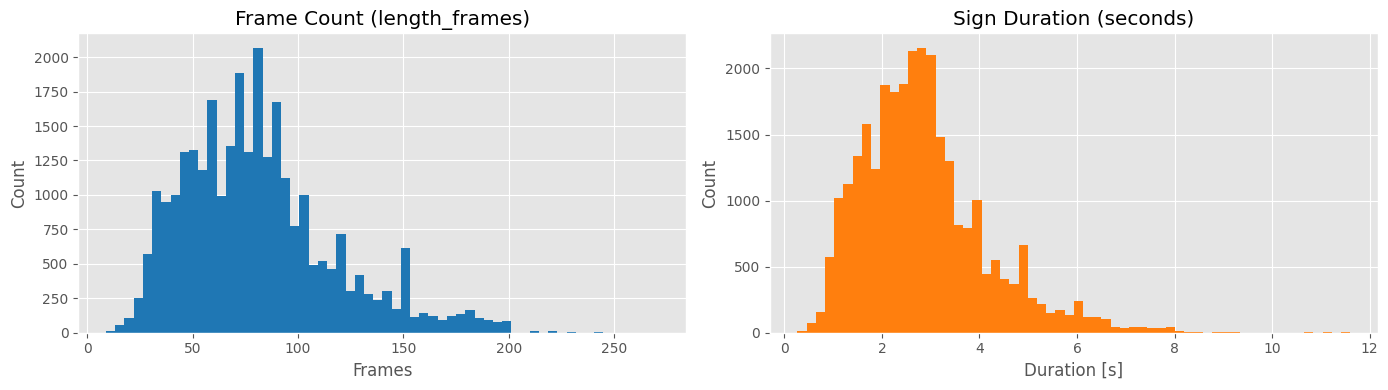

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['length_frames'].dropna().hist(bins=60, ax=axes[0], color='#1f77b4')
axes[0].set_title('Frame Count (length_frames)')
axes[0].set_xlabel('Frames')
axes[0].set_ylabel('Count')

df['duration_sec'].dropna().hist(bins=60, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Sign Duration (seconds)')
axes[1].set_xlabel('Duration [s]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

## 3. FPS Distribution

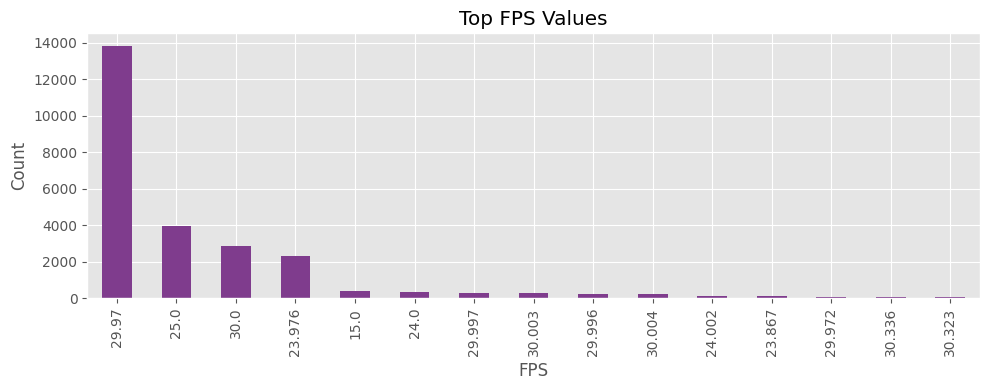

In [6]:
fps_counts = df['fps'].round(3).value_counts().sort_values(ascending=False)
plot_top_bar(
    fps_counts,
    title='Top FPS Values',
    xlabel='FPS',
    ylabel='Count',
    top_n=15,
    color='#7f3c8d'
 )

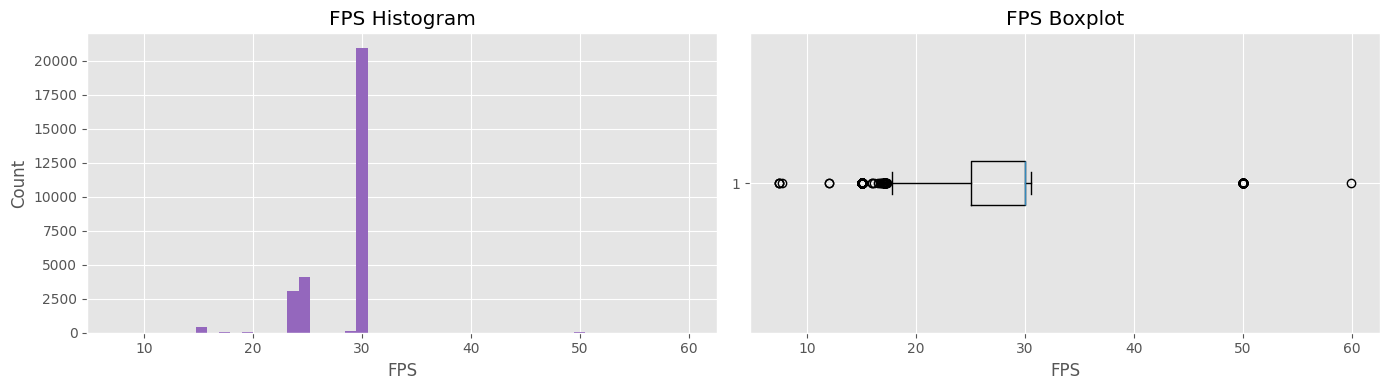

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df['fps'].dropna().hist(bins=50, ax=axes[0], color='#9467bd')
axes[0].set_title('FPS Histogram')
axes[0].set_xlabel('FPS')
axes[0].set_ylabel('Count')

axes[1].boxplot(df['fps'].dropna(), vert=False)
axes[1].set_title('FPS Boxplot')
axes[1].set_xlabel('FPS')

plt.tight_layout()
plt.show()

## 4. Samples per Class

Unique classes: 2054
Mean samples/class: 13.99
Median samples/class: 8.0


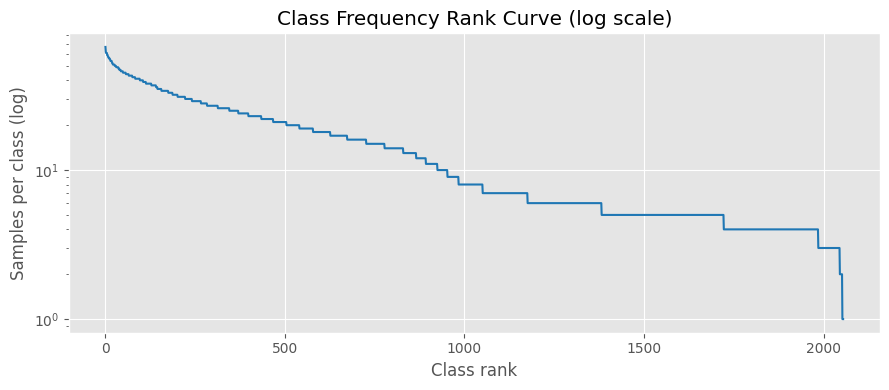

In [8]:
label_counts = df['label'].value_counts()

print('Unique classes:', df['label'].nunique())
print('Mean samples/class:', round(label_counts.mean(), 2))
print('Median samples/class:', round(label_counts.median(), 2))

rank_curve = label_counts.sort_values(ascending=False).reset_index(drop=True)
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(np.arange(1, len(rank_curve) + 1), rank_curve.values, color='#1f77b4')
ax.set_yscale('log')
ax.set_title('Class Frequency Rank Curve (log scale)')
ax.set_xlabel('Class rank')
ax.set_ylabel('Samples per class (log)')
plt.tight_layout()
plt.show()

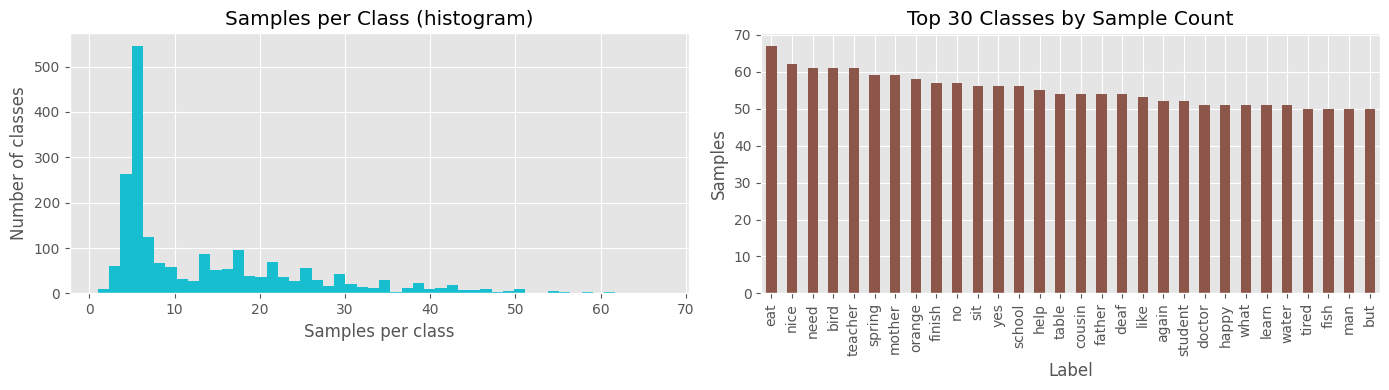

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

label_counts.hist(bins=50, ax=axes[0], color='#17becf')
axes[0].set_title('Samples per Class (histogram)')
axes[0].set_xlabel('Samples per class')
axes[0].set_ylabel('Number of classes')

label_counts.sort_values(ascending=False).head(30).plot(kind='bar', ax=axes[1], color='#8c564b')
axes[1].set_title('Top 30 Classes by Sample Count')
axes[1].set_xlabel('Label')
axes[1].set_ylabel('Samples')

plt.tight_layout()
plt.show()

## 5. Signer vs Label

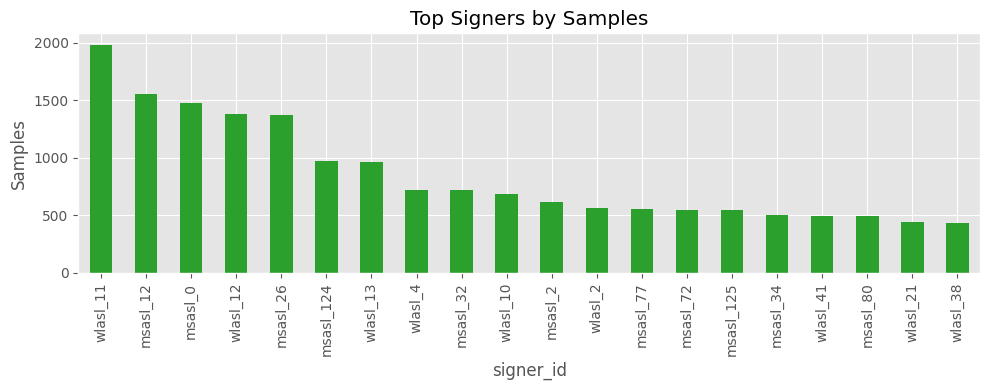

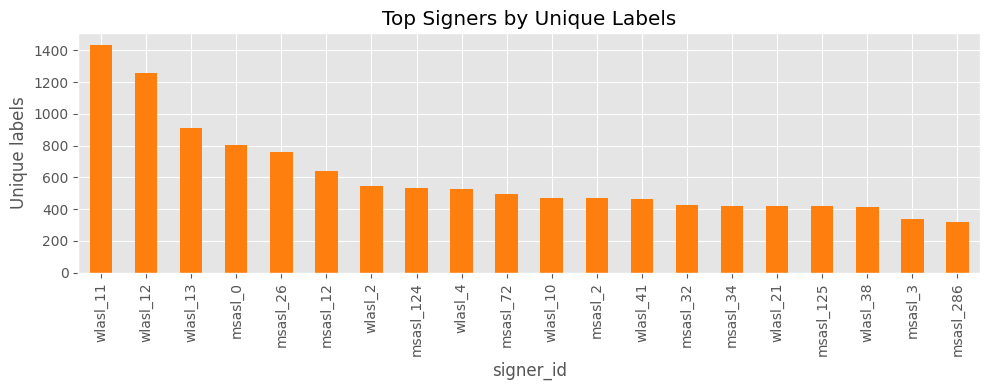

In [10]:
signer_counts = df['signer_id'].value_counts(dropna=False)
labels_per_signer = df.groupby('signer_id')['label'].nunique().sort_values(ascending=False)

plot_top_bar(
    signer_counts,
    title='Top Signers by Samples',
    xlabel='signer_id',
    ylabel='Samples',
    top_n=20,
    color='#2ca02c'
 )

plot_top_bar(
    labels_per_signer,
    title='Top Signers by Unique Labels',
    xlabel='signer_id',
    ylabel='Unique labels',
    top_n=20,
    color='#ff7f0e'
 )

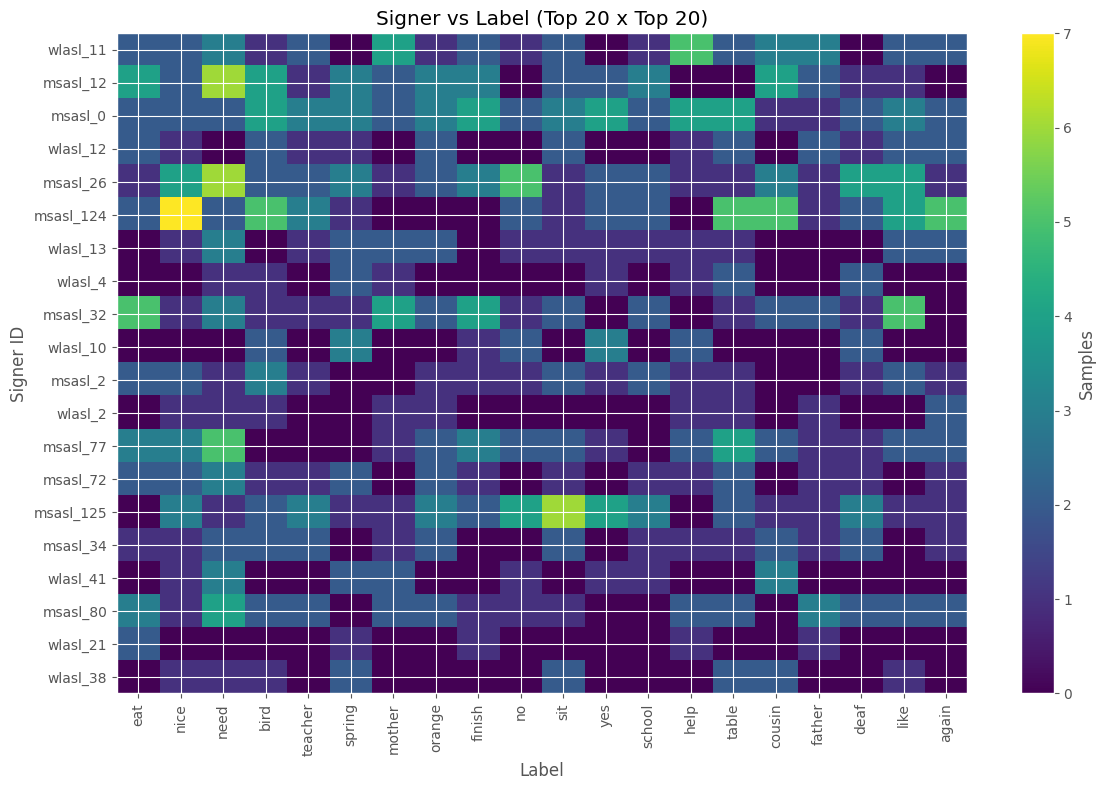

In [11]:
top_signers = signer_counts.head(20).index
top_labels = label_counts.head(20).index

heat = pd.crosstab(df['signer_id'], df['label']).reindex(index=top_signers, columns=top_labels, fill_value=0)

fig, ax = plt.subplots(figsize=(12, 8))
im = ax.imshow(heat.values, aspect='auto')
ax.set_title('Signer vs Label (Top 20 x Top 20)')
ax.set_xlabel('Label')
ax.set_ylabel('Signer ID')
ax.set_xticks(np.arange(len(heat.columns)))
ax.set_xticklabels(heat.columns, rotation=90)
ax.set_yticks(np.arange(len(heat.index)))
ax.set_yticklabels(heat.index)
fig.colorbar(im, ax=ax, label='Samples')
plt.tight_layout()
plt.show()

In [12]:
contingency = pd.crosstab(df['signer_id'], df['label'])
chi2, p_value, dof, _ = chi2_contingency(contingency)
n = contingency.values.sum()
r, k = contingency.shape
cramers_v = np.sqrt((chi2 / n) / max(min(r - 1, k - 1), 1))

print(f'Chi2: {chi2:.2f}')
print(f'p-value: {p_value:.6e}')
print(f"Cramer's V: {cramers_v:.4f}")

if cramers_v < 0.1:
    print('Interpretation: very weak association')
elif cramers_v < 0.3:
    print('Interpretation: weak/moderate association')
elif cramers_v < 0.5:
    print('Interpretation: moderate/strong association')
else:
    print('Interpretation: strong association')

Chi2: 477879.64
p-value: 1.259005e-46
Cramer's V: 0.2712
Interpretation: weak/moderate association


## 6. Video Dimensions

Samples with known dimensions: 28745


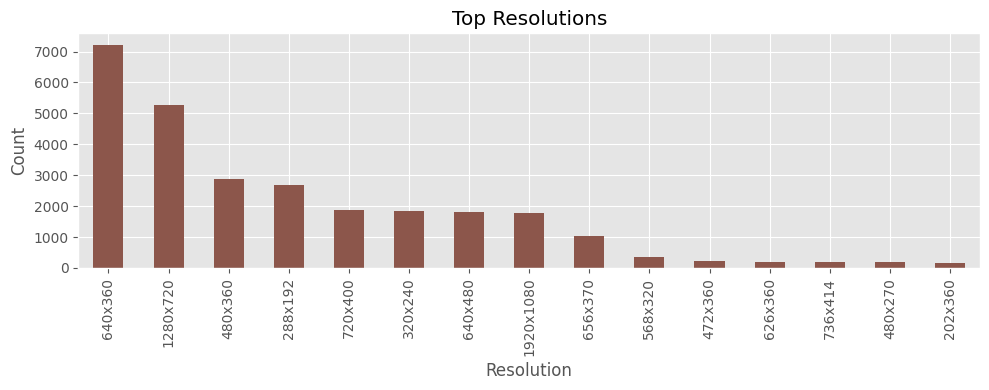

In [13]:
size_df = df[['video_width', 'video_height']].dropna()
print('Samples with known dimensions:', len(size_df))

top_res = (
    df.dropna(subset=['video_width', 'video_height'])
    .assign(res=lambda x: x['video_width'].astype(int).astype(str) + 'x' + x['video_height'].astype(int).astype(str))['res']
    .value_counts()
 )

plot_top_bar(
    top_res,
    title='Top Resolutions',
    xlabel='Resolution',
    ylabel='Count',
    top_n=15,
    color='#8c564b'
 )

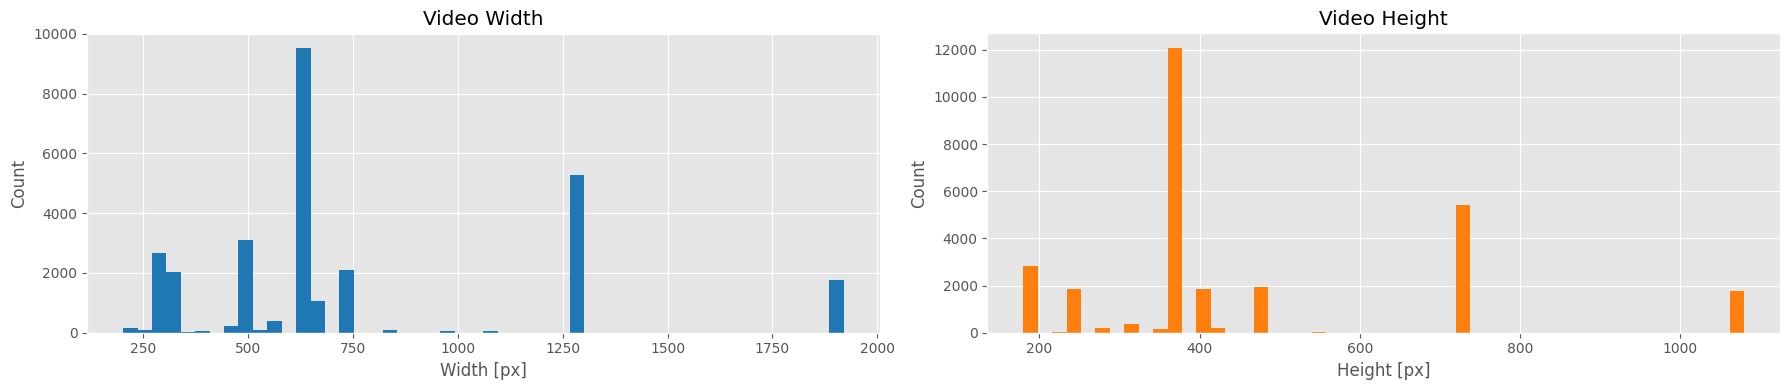

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(18, 4))

df['video_width'].dropna().hist(bins=50, ax=axes[0], color='#1f77b4')
axes[0].set_title('Video Width')
axes[0].set_xlabel('Width [px]')
axes[0].set_ylabel('Count')

df['video_height'].dropna().hist(bins=50, ax=axes[1], color='#ff7f0e')
axes[1].set_title('Video Height')
axes[1].set_xlabel('Height [px]')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

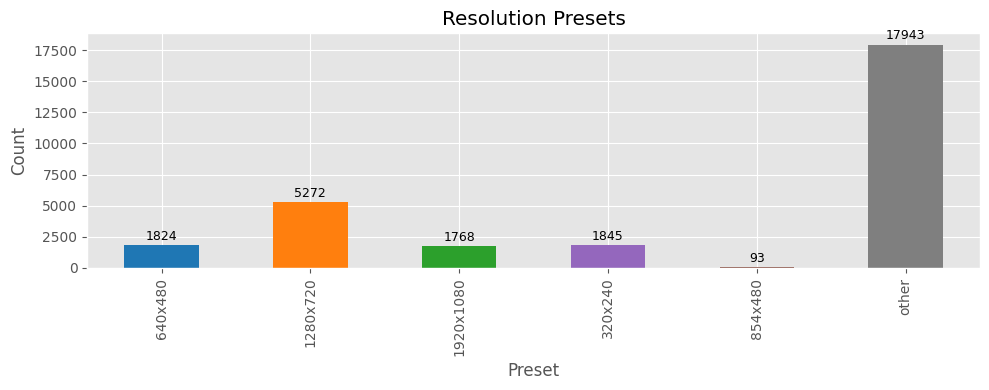

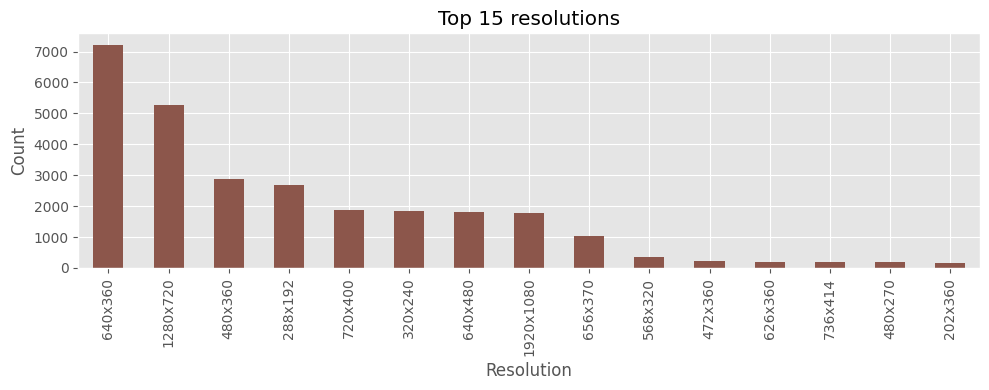

In [15]:
res_df = df.dropna(subset=['video_width', 'video_height']).copy()
res_df = res_df[(res_df['video_width'] > 0) & (res_df['video_height'] > 0)]
res_df['resolution'] = res_df['video_width'].astype(int).astype(str) + 'x' + res_df['video_height'].astype(int).astype(str)

preset_order = ['640x480', '1280x720', '1920x1080', '320x240', '854x480']
preset_counts = res_df['resolution'].value_counts()

preset_plot = pd.Series({preset: int(preset_counts.get(preset, 0)) for preset in preset_order})
other_count = int(len(res_df) - preset_plot.sum())
preset_plot['other'] = other_count

fig, ax = plt.subplots(figsize=(10, 4))
preset_plot.plot(kind='bar', ax=ax, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#8c564b', '#7f7f7f'])
ax.set_title('Resolution Presets')
ax.set_xlabel('Preset')
ax.set_ylabel('Count')

for i, val in enumerate(preset_plot.values):
    ax.text(i, val + max(1, 0.01 * max(preset_plot.values)), str(val), ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

plot_top_bar(
    preset_counts,
    title='Top 15 resolutions',
    xlabel='Resolution',
    ylabel='Count',
    top_n=15,
    color='#8c564b'
 )

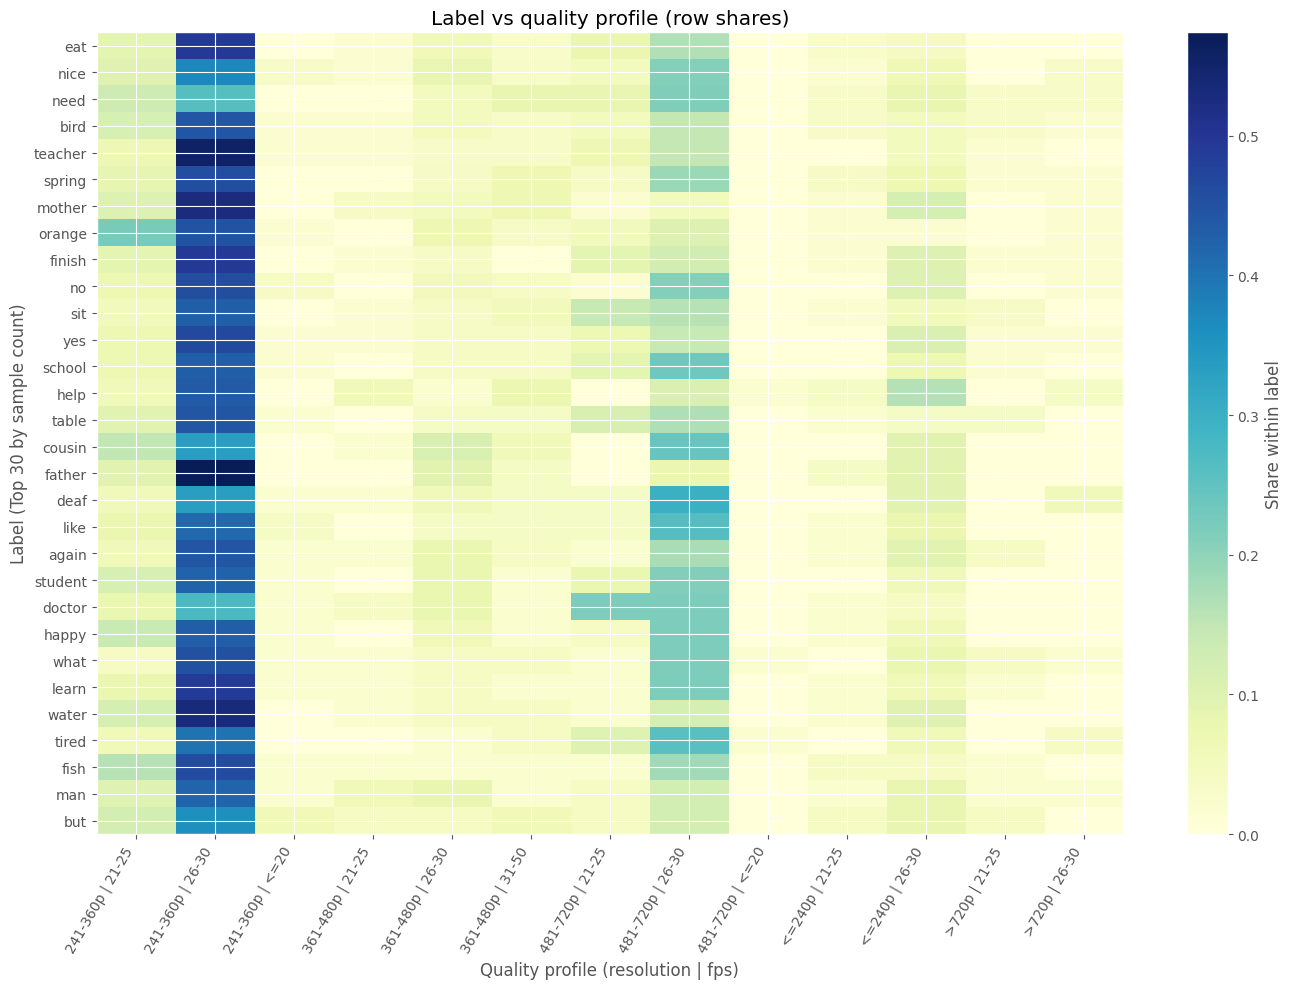

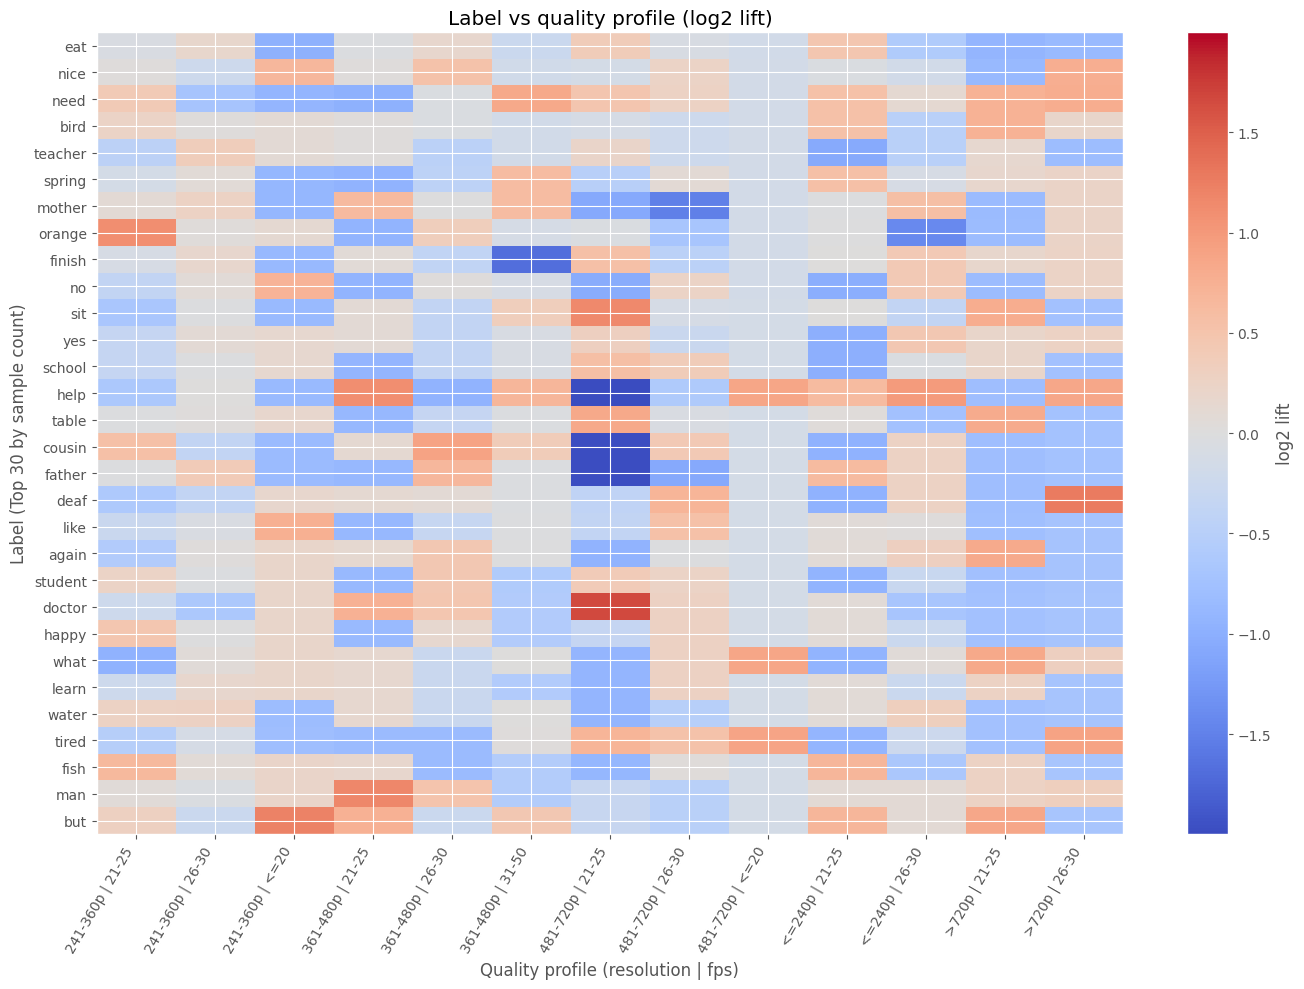

Chi2=338.20, dof=348, p-value=6.367e-01, Cramers V=0.1306


quality_bin,241-360p | 21-25,241-360p | 26-30,241-360p | <=20,361-480p | 21-25,361-480p | 26-30,361-480p | 31-50,481-720p | 21-25,481-720p | 26-30,481-720p | <=20,<=240p | 21-25,<=240p | 26-30,>720p | 21-25,>720p | 26-30
label,,,,,,,,,,,,,
eat,0.089552,0.492537,0.000000,0.014925,0.059701,0.029851,0.074627,0.164179,0.0,0.029851,0.044776,0.000000,0.000000
nice,0.096774,0.370968,0.032258,0.016129,0.080645,0.032258,0.048387,0.209677,0.0,0.016129,0.064516,0.000000,0.032258
need,0.131148,0.262295,0.000000,0.000000,0.049180,0.081967,0.081967,0.213115,0.0,0.032787,0.081967,0.032787,0.032787
bird,0.114754,0.442623,0.016393,0.016393,0.049180,0.032787,0.049180,0.147541,0.0,0.032787,0.049180,0.032787,0.016393
teacher,0.065574,0.557377,0.016393,0.016393,0.032787,0.032787,0.065574,0.147541,0.0,0.000000,0.049180,0.016393,0.000000
spring,0.084746,0.457627,0.000000,0.000000,0.033898,0.067797,0.033898,0.186441,0.0,0.033898,0.067797,0.016949,0.016949
mother,0.101695,0.525424,0.000000,0.033898,0.050847,0.067797,0.016949,0.050847,0.0,0.016949,0.118644,0.000000,0.016949
orange,0.224138,0.448276,0.017241,0.000000,0.068966,0.034483,0.051724,0.103448,0.0,0.017241,0.017241,0.000000,0.017241
finish,0.087719,0.491228,0.000000,0.017544,0.035088,0.000000,0.087719,0.122807,0.0,0.017544,0.105263,0.017544,0.017544


quality_bin,241-360p | 21-25,241-360p | 26-30,241-360p | <=20,361-480p | 21-25,361-480p | 26-30,361-480p | 31-50,481-720p | 21-25,481-720p | 26-30,481-720p | <=20,<=240p | 21-25,<=240p | 26-30,>720p | 21-25,>720p | 26-30
label,,,,,,,,,,,,,
eat,-0.073053,0.171784,-0.980228,-0.038325,0.169663,-0.260657,0.368379,-0.087959,-0.165555,0.463656,-0.581467,-0.919692,-0.856506
nice,0.023126,-0.222673,0.658825,0.018004,0.518652,-0.180778,-0.129507,0.237233,-0.153835,-0.061928,-0.166955,-0.868028,0.777483
need,0.405726,-0.697558,-0.915071,-0.970462,-0.048488,0.835743,0.473519,0.258702,-0.151479,0.535209,0.115332,0.727493,0.787491
bird,0.235801,0.022334,0.084929,0.029538,-0.048488,-0.164257,-0.111443,-0.226725,-0.151479,0.535209,-0.469631,0.727493,0.202529
teacher,-0.442271,0.344262,0.084929,0.029538,-0.463525,-0.164257,0.210485,-0.226725,-0.151479,-1.049753,-0.469631,0.142531,-0.797471
spring,-0.138323,0.068656,-0.892682,-0.947112,-0.427205,0.606328,-0.489660,0.080231,-0.146757,0.559872,-0.108411,0.163883,0.222756
mother,0.084069,0.261301,-0.892682,0.637850,-0.012167,0.606328,-1.074622,-1.504732,-0.146757,-0.025091,0.569661,-0.836117,0.222756
orange,1.104970,0.039919,0.118644,-0.935294,0.328270,-0.113529,-0.055853,-0.674905,-0.144390,-0.012600,-1.410284,-0.825321,0.232977
finish,-0.096215,0.167140,-0.869939,0.076621,-0.389947,-1.681178,0.548126,-0.459432,-0.142019,0.000000,0.417408,0.185556,0.243271


In [16]:
required_cols = ['label', 'video_width', 'video_height', 'fps']
missing = [c for c in required_cols if c not in df.columns]
if len(missing) > 0:
    raise ValueError(f'Missing columns for quality-bias analysis: {missing}')

quality_df = df.copy()
quality_df['label'] = quality_df['label'].astype(str).str.strip().str.lower()
quality_df['video_width'] = pd.to_numeric(quality_df['video_width'], errors='coerce')
quality_df['video_height'] = pd.to_numeric(quality_df['video_height'], errors='coerce')
quality_df['fps'] = pd.to_numeric(quality_df['fps'], errors='coerce')

quality_df = quality_df.dropna(subset=['label', 'video_width', 'video_height', 'fps']).copy()
quality_df = quality_df[(quality_df['video_width'] > 0) & (quality_df['video_height'] > 0) & (quality_df['fps'] > 0)].copy()

short_side = np.minimum(quality_df['video_width'], quality_df['video_height'])
quality_df['res_bin'] = pd.cut(
    short_side,
    bins=[0, 240, 360, 480, 720, np.inf],
    labels=['<=240p', '241-360p', '361-480p', '481-720p', '>720p'],
    include_lowest=True,
 )

quality_df['fps_bin'] = pd.cut(
    quality_df['fps'],
    bins=[0, 20, 25, 30, 50, np.inf],
    labels=['<=20', '21-25', '26-30', '31-50', '>50'],
    include_lowest=True,
 )

quality_df['quality_bin'] = quality_df['res_bin'].astype(str) + ' | ' + quality_df['fps_bin'].astype(str)

TOP_LABELS = 30
top_labels = quality_df['label'].value_counts().head(TOP_LABELS).index.tolist()
quality_top = quality_df[quality_df['label'].isin(top_labels)].copy()

cont = pd.crosstab(quality_top['label'], quality_top['quality_bin'])
cont = cont.loc[top_labels]

if cont.shape[0] == 0 or cont.shape[1] == 0:
    raise ValueError('Not enough data to build quality profile heatmaps.')

row_share = cont.div(cont.sum(axis=1), axis=0).fillna(0.0)
fig, ax = plt.subplots(figsize=(14, max(6, int(0.35 * len(row_share)))))
im = ax.imshow(row_share.values, aspect='auto', cmap='YlGnBu', vmin=0, vmax=max(0.01, float(row_share.values.max())))
ax.set_title('Label vs quality profile (row shares)')
ax.set_xlabel('Quality profile (resolution | fps)')
ax.set_ylabel('Label (Top 30 by sample count)')
ax.set_xticks(np.arange(len(row_share.columns)))
ax.set_xticklabels(row_share.columns, rotation=60, ha='right')
ax.set_yticks(np.arange(len(row_share.index)))
ax.set_yticklabels(row_share.index)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('Share within label')
plt.tight_layout()
plt.show()

observed = cont.astype(float)
n = observed.values.sum()
row_tot = observed.sum(axis=1).values.reshape(-1, 1)
col_tot = observed.sum(axis=0).values.reshape(1, -1)
expected = (row_tot @ col_tot) / max(n, 1.0)

lift = np.log2((observed.values + 1.0) / (expected + 1.0))
lift_df = pd.DataFrame(lift, index=observed.index, columns=observed.columns)

fig, ax = plt.subplots(figsize=(14, max(6, int(0.35 * len(lift_df)))))
v = float(np.nanmax(np.abs(lift_df.values))) if lift_df.size else 1.0
v = max(v, 0.25)
im = ax.imshow(lift_df.values, aspect='auto', cmap='coolwarm', vmin=-v, vmax=v)
ax.set_title('Label vs quality profile (log2 lift)')
ax.set_xlabel('Quality profile (resolution | fps)')
ax.set_ylabel('Label (Top 30 by sample count)')
ax.set_xticks(np.arange(len(lift_df.columns)))
ax.set_xticklabels(lift_df.columns, rotation=60, ha='right')
ax.set_yticks(np.arange(len(lift_df.index)))
ax.set_yticklabels(lift_df.index)
cbar = fig.colorbar(im, ax=ax)
cbar.set_label('log2 lift')
plt.tight_layout()
plt.show()

chi2, p_value, dof, _ = chi2_contingency(observed.values)
r, k = observed.shape
phi2 = chi2 / max(n, 1.0)
cramers_v = np.sqrt(phi2 / max(min(r - 1, k - 1), 1))

print(f'Chi2={chi2:.2f}, dof={dof}, p-value={p_value:.3e}, Cramers V={cramers_v:.4f}')
display(row_share.head(10))
display(lift_df.head(10))

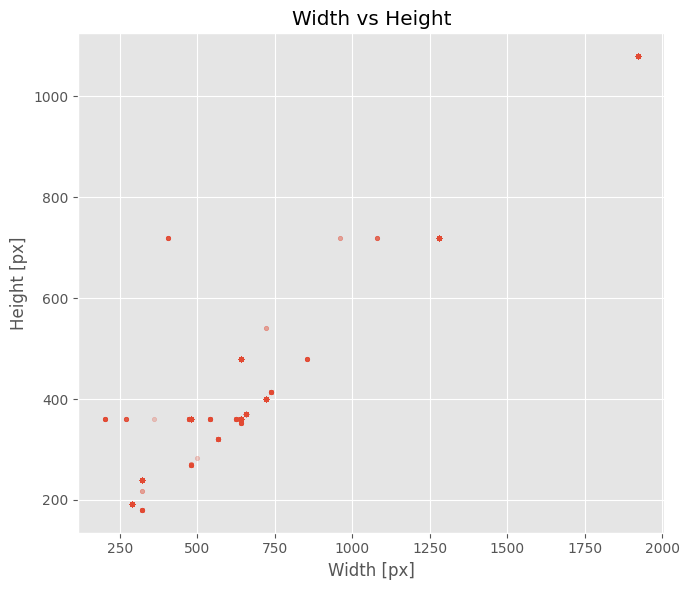

In [17]:
sample_scatter = df.dropna(subset=['video_width', 'video_height']).sample(min(3000, df.dropna(subset=['video_width', 'video_height']).shape[0]), random_state=42)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(sample_scatter['video_width'], sample_scatter['video_height'], alpha=0.25, s=10)
ax.set_title('Width vs Height')
ax.set_xlabel('Width [px]')
ax.set_ylabel('Height [px]')
plt.tight_layout()
plt.show()

## 7. Numeric Correlations

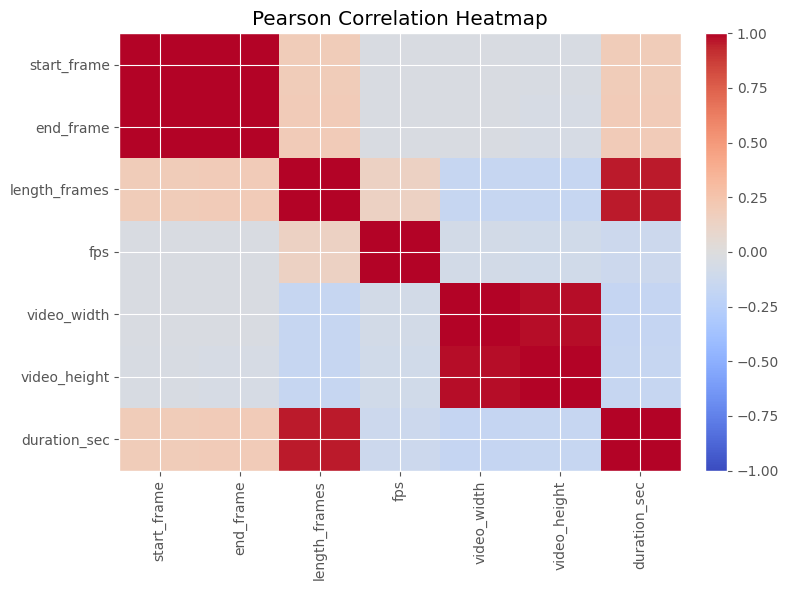

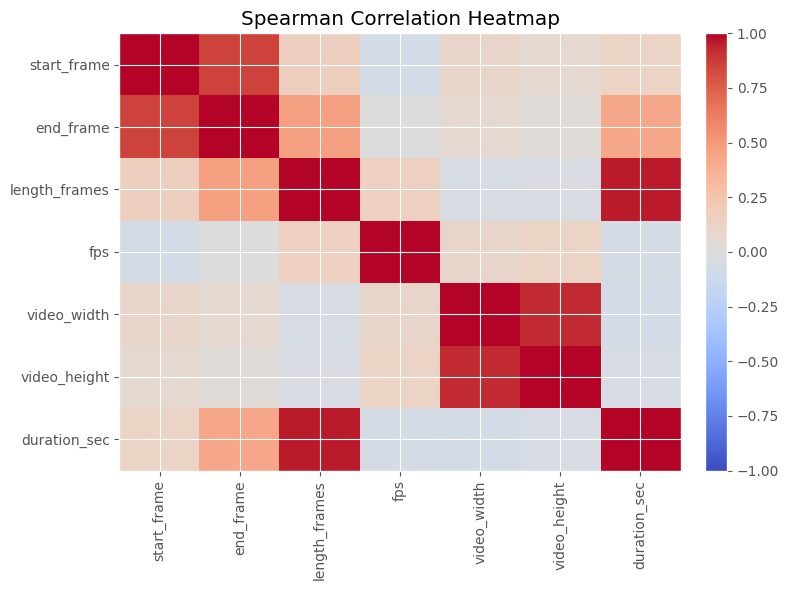

In [18]:
num_cols = ['start_frame', 'end_frame', 'length_frames', 'fps', 'video_width', 'video_height', 'duration_sec']
num_df = df[num_cols].copy()

pearson_corr = num_df.corr(method='pearson')
spearman_corr = num_df.corr(method='spearman')

plot_heatmap(pearson_corr.fillna(0), 'Pearson Correlation Heatmap', cmap='coolwarm', vmin=-1, vmax=1)
plot_heatmap(spearman_corr.fillna(0), 'Spearman Correlation Heatmap', cmap='coolwarm', vmin=-1, vmax=1)

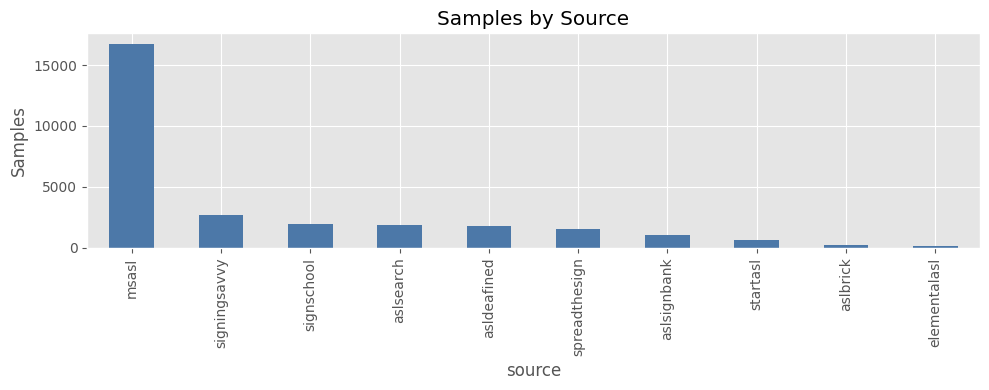

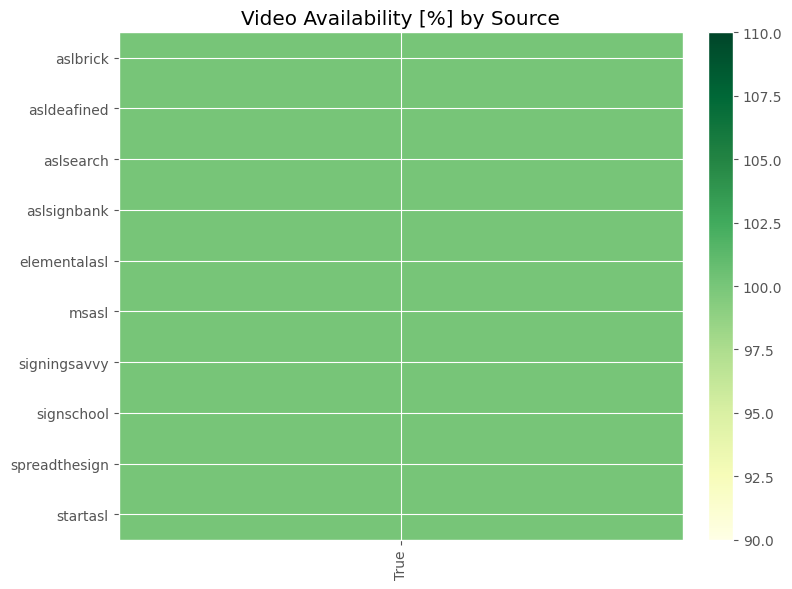

In [19]:
source_counts = df['source'].value_counts()
plot_top_bar(
    source_counts,
    title='Samples by Source',
    xlabel='source',
    ylabel='Samples',
    top_n=len(source_counts),
    color='#4c78a8'
 )

source_avail = pd.crosstab(df['source'], df['has_video'], normalize='index') * 100
plot_heatmap(source_avail.round(2), 'Video Availability [%] by Source', cmap='YlGn')

## 8. Label vs Sign Duration

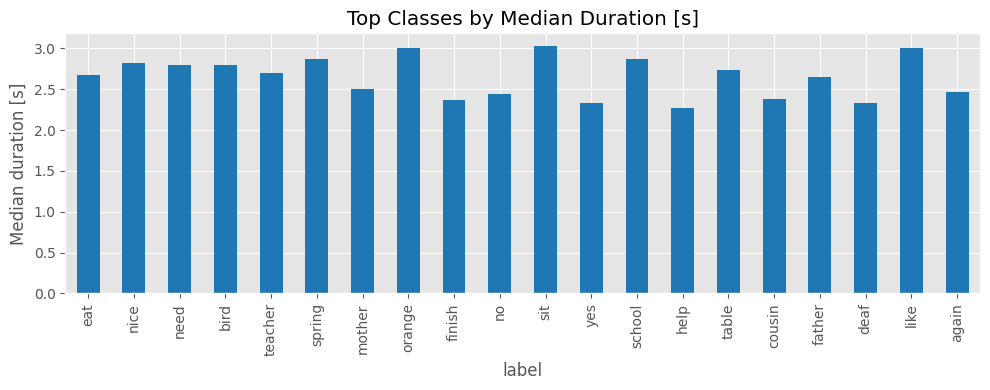

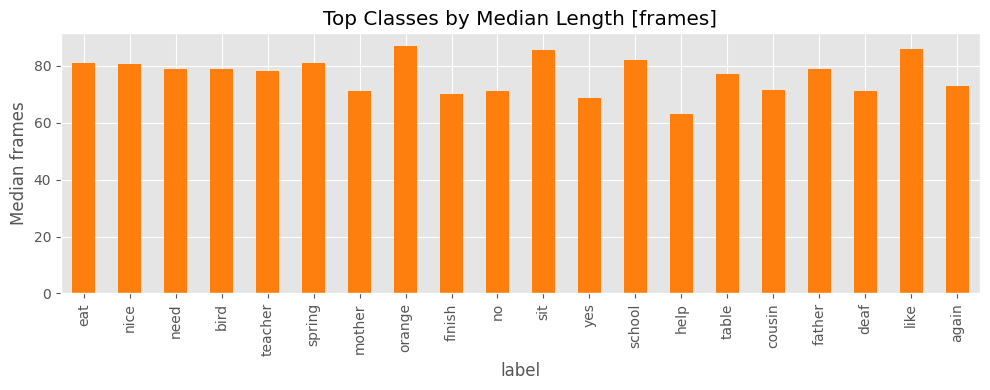

Spearman(samples, median_duration) for classes with >= 10 samples: rho=-0.0238, p-value=4.6317e-01


In [20]:
base_df = df_existing.copy() if 'df_existing' in globals() else df[df['has_video'] == True].copy()
label_duration_df = base_df.dropna(subset=['label', 'duration_sec']).copy()
label_length_df = base_df.dropna(subset=['label', 'length_frames']).copy()

label_duration_stats = label_duration_df.groupby('label').agg(
    samples=('duration_sec', 'size'),
    mean_duration=('duration_sec', 'mean'),
    median_duration=('duration_sec', 'median'),
    std_duration=('duration_sec', 'std'),
).sort_values('samples', ascending=False)

label_length_stats = label_length_df.groupby('label').agg(
    samples=('length_frames', 'size'),
    mean_frames=('length_frames', 'mean'),
    median_frames=('length_frames', 'median'),
    std_frames=('length_frames', 'std'),
).sort_values('samples', ascending=False)

plot_top_bar(
    label_duration_stats['median_duration'],
    title='Top Classes by Median Duration [s]',
    xlabel='label',
    ylabel='Median duration [s]',
    top_n=20,
    color='#1f77b4'
 )

plot_top_bar(
    label_length_stats['median_frames'],
    title='Top Classes by Median Length [frames]',
    xlabel='label',
    ylabel='Median frames',
    top_n=20,
    color='#ff7f0e'
 )

min_samples = 10
duration_corr_df = label_duration_stats[label_duration_stats['samples'] >= min_samples].copy()

if len(duration_corr_df) >= 3:
    rho, p_val = spearmanr(duration_corr_df['samples'], duration_corr_df['median_duration'])
    print(f'Spearman(samples, median_duration) for classes with >= {min_samples} samples: rho={rho:.4f}, p-value={p_val:.4e}')
else:
    print('Too few classes after filtering for Spearman correlation.')

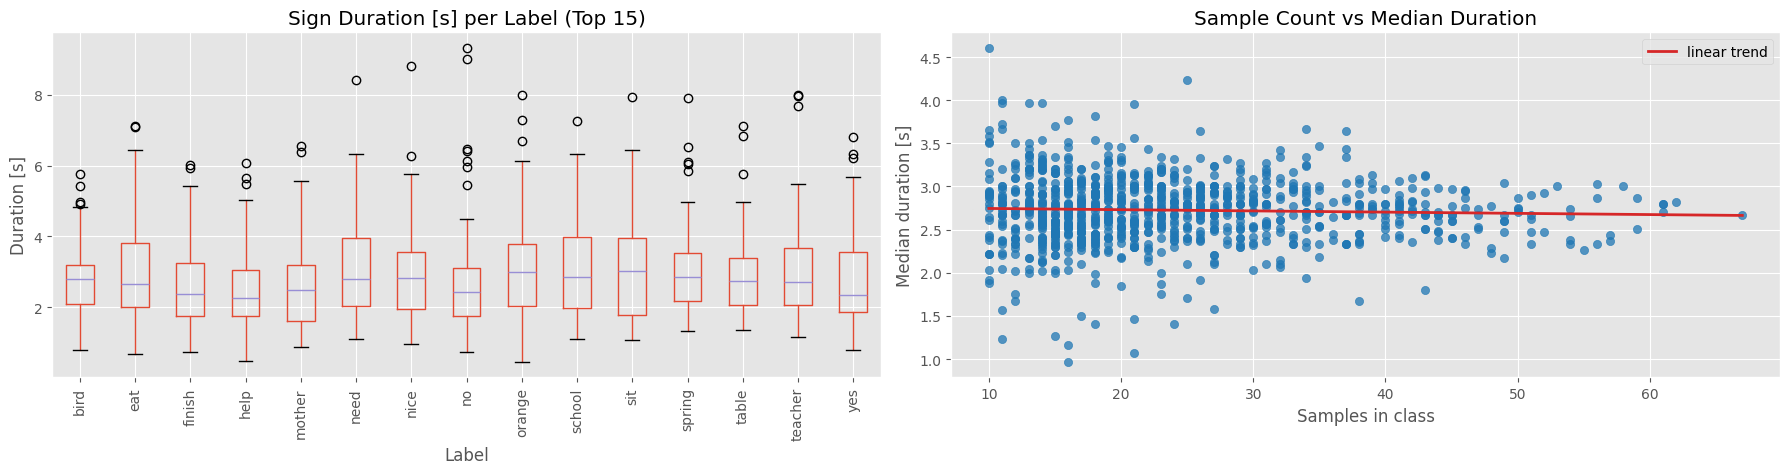

In [21]:
top_labels_by_samples = label_duration_stats.head(15).index
plot_df = label_duration_df[label_duration_df['label'].isin(top_labels_by_samples)].copy()

fig, axes = plt.subplots(1, 2, figsize=(18, 5))

plot_df.boxplot(column='duration_sec', by='label', ax=axes[0], rot=90)
axes[0].set_title('Sign Duration [s] per Label (Top 15)')
axes[0].set_xlabel('Label')
axes[0].set_ylabel('Duration [s]')

axes[1].scatter(
    duration_corr_df['samples'],
    duration_corr_df['median_duration'],
    alpha=0.75,
    s=35,
    color='#1f77b4'
)
axes[1].set_title('Sample Count vs Median Duration')
axes[1].set_xlabel('Samples in class')
axes[1].set_ylabel('Median duration [s]')

if len(duration_corr_df) >= 2:
    m, b = np.polyfit(duration_corr_df['samples'], duration_corr_df['median_duration'], 1)
    x = np.linspace(duration_corr_df['samples'].min(), duration_corr_df['samples'].max(), 100)
    axes[1].plot(x, m * x + b, color='#d62728', linewidth=2, label='linear trend')
    axes[1].legend()

plt.suptitle('')
plt.tight_layout()
plt.show()